# Fast CNN Classifier: Synthetic vs Original Mammograms

This notebook performs a fair PNG vs PNG comparison with optimized settings for faster training.


In [1]:
# Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.pyplot import imshow

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


2025-10-19 18:33:55.513599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760913235.531655 3887565 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760913235.537221 3887565 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760913235.551100 3887565 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760913235.551118 3887565 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760913235.551120 3887565 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Setup - Limited Dataset for Speed


In [2]:
# Data paths
DATAFOLDER = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/classifier_data'
os.makedirs(f'{DATAFOLDER}/train/synthetic', exist_ok=True)
os.makedirs(f'{DATAFOLDER}/train/original', exist_ok=True)
os.makedirs(f'{DATAFOLDER}/test/synthetic', exist_ok=True)
os.makedirs(f'{DATAFOLDER}/test/original', exist_ok=True)


In [3]:
# Load and limit dataset for faster training
synthetic_files = glob.glob('/raid/mpsych/OMAMA/DATA/data/train/*.png')[:5000]  # Reduced for speed
original_files = glob.glob('/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original/*.png')[:5000]  # Reduced for speed

print(f"Limited dataset - Synthetic files: {len(synthetic_files)}")
print(f"Limited dataset - Original files: {len(original_files)}")

# Split data
synthetic_train, synthetic_test = train_test_split(synthetic_files, test_size=0.2, random_state=42)
original_train, original_test = train_test_split(original_files, test_size=0.2, random_state=42)

print(f"Training: {len(synthetic_train)} synthetic, {len(original_train)} original")
print(f"Testing: {len(synthetic_test)} synthetic, {len(original_test)} original")


Limited dataset - Synthetic files: 5000
Limited dataset - Original files: 5000
Training: 4000 synthetic, 4000 original
Testing: 1000 synthetic, 1000 original


In [4]:
# Clear existing files and create symlinks
for folder in [f'{DATAFOLDER}/train/synthetic', f'{DATAFOLDER}/train/original', 
               f'{DATAFOLDER}/test/synthetic', f'{DATAFOLDER}/test/original']:
    if os.path.exists(folder):
        for file in os.listdir(folder):
            file_path = os.path.join(folder, file)
            if os.path.islink(file_path):
                os.unlink(file_path)
            else:
                os.remove(file_path)

# Create symlinks for faster setup
print("Creating symlinks...")
for file_path in synthetic_train:
    os.symlink(file_path, f'{DATAFOLDER}/train/synthetic/{os.path.basename(file_path)}')
for file_path in synthetic_test:
    os.symlink(file_path, f'{DATAFOLDER}/test/synthetic/{os.path.basename(file_path)}')
for file_path in original_train:
    os.symlink(file_path, f'{DATAFOLDER}/train/original/{os.path.basename(file_path)}')
for file_path in original_test:
    os.symlink(file_path, f'{DATAFOLDER}/test/original/{os.path.basename(file_path)}')

print("Symlinks created successfully!")


Creating symlinks...
Symlinks created successfully!


## Data Generators with Optimized Settings


In [5]:
# Optimized data generators for faster training
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,  # Reduced for speed
    width_shift_range=0.1,  # Reduced for speed
    height_shift_range=0.1,  # Reduced for speed
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,  # Reduced for speed
    shear_range=0.05,  # Reduced for speed
    brightness_range=[0.9, 1.1],  # Reduced for speed
    fill_mode='nearest'
)

X_train = train_generator.flow_from_directory(
    DATAFOLDER+'/train', 
    color_mode='grayscale', 
    target_size=(512,512), 
    batch_size=64,  # Increased batch size for speed
    class_mode='categorical'
)

test_generator = ImageDataGenerator(rescale=1./255)
X_test = test_generator.flow_from_directory(
    DATAFOLDER+'/test', 
    color_mode='grayscale', 
    target_size=(512,512), 
    batch_size=64,  # Increased batch size for speed
    class_mode='categorical'
)

print(f"Training batches: {X_train.n}")
print(f"Test batches: {X_test.n}")
print(f"Classes: {X_train.class_indices}")


Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Training batches: 8000
Test batches: 2000
Classes: {'original': 0, 'synthetic': 1}


## Optimized Model Architecture


In [6]:
# Get first image shape
first_batch = next(X_train)
first_image = first_batch[0][0]
print(f"Image shape: {first_image.shape}")

NUMBER_OF_CLASSES = 2

# Optimized model for faster training
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=first_image.shape))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(0.25))

model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Dropout(0.25))

model.add(keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.GlobalAveragePooling2D())
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(32, activation='relu'))  # Reduced for speed
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(NUMBER_OF_CLASSES, activation='softmax'))

# Compile with optimized settings
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Higher LR for speed
    metrics=['accuracy']
)

model.summary()


Image shape: (512, 512, 1)


/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1760913252.199120 3887565 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:47:00.0, compute capability: 8.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 510, 510, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 253, 253, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 124, 124, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,762 (381.88 KB)

 Trainable params: 97,314 (380.13 KB)

 Non-trainable params: 448 (1.75 KB)

## Fast Training with Early Stopping


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Aggressive early stopping for speed
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=2,  # Very aggressive
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=1, 
    min_lr=0.0001, 
    verbose=1
)

# Fast training
print("Starting fast training...")
history = model.fit(
    X_train, 
    epochs=10,  # Reduced epochs
    validation_data=X_test, 
    callbacks=[early_stopping, reduce_lr], 
    verbose=1
)

print("Training completed!")


Starting fast training...


/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1760913257.602297 3888301 service.cc:152] XLA service 0x7f9d800140c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760913257.602332 3888301 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-10-19 18:34:17.679407: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760913258.067058 3888301 cuda_dnn.cc:529] Loaded cuDNN version 90300
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName
E0000 00:00:1760913265.421161 3888301 buffer_comparator.cc:156] Difference at 0: 4.19633e+06, expected 3.43022e+06
E0000 00:00:1760913265.421216 3888301 buffer_comparator.cc:156] Difference at 1: 4.19652e+06, expected 3.43019e+06
E0000 00:00:1760913265.421220 3888301 buffer_comparator.cc:156] Difference at 2: 4.19643e

  1/125 ━━━━━━━━━━━━━━━━━━━━ 43:40 21s/step - accuracy: 0.3125 - loss: 0.8055

I0000 00:00:1760913276.240555 3888301 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.9099 - loss: 0.2227

2025-10-19 18:36:45.195999: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_154', 4 bytes spill stores, 4 bytes spill loads



125/125 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9104 - loss: 0.2218 - val_accuracy: 0.5000 - val_loss: 5.3144 - learning_rate: 0.0010
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.9937 - loss: 0.0238
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 966ms/step - accuracy: 0.9937 - loss: 0.0238 - val_accuracy: 0.5000 - val_loss: 9.0913 - learning_rate: 0.0010
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.9976 - loss: 0.0105
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 968ms/step - accuracy: 0.9976 - loss: 0.0105 - val_accuracy: 0.5010 - val_loss: 10.0510 - learning_rate: 5.0000e-04
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.9993 - loss: 0.0056
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
125/125 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9993 - loss: 0.

## Training Visualization


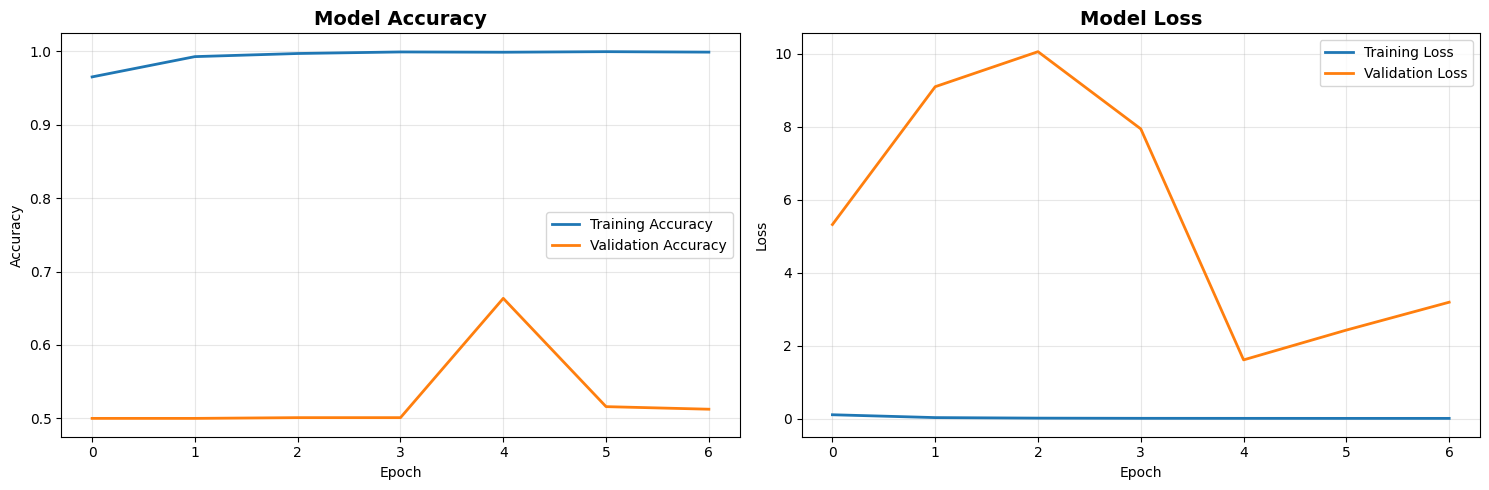


Final Training Accuracy: 0.9989
Final Validation Accuracy: 0.5125


In [8]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


## Model Evaluation


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.6538 - loss: 1.6964

Test Accuracy: 0.6635
Test Loss: 1.6065
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step


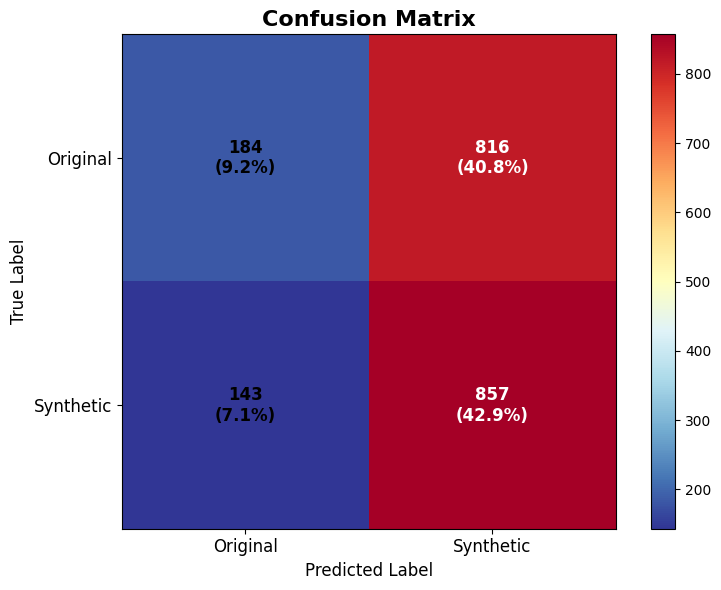


Classification Report:
              precision    recall  f1-score   support

    Original       0.56      0.18      0.28      1000
   Synthetic       0.51      0.86      0.64      1000

    accuracy                           0.52      2000
   macro avg       0.54      0.52      0.46      2000
weighted avg       0.54      0.52      0.46      2000



In [9]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = X_test.classes

# Confusion Matrix with correct class labels
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='RdYlBu_r')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.colorbar()

# Get class names from generator in correct order
class_labels = list(X_test.class_indices.keys())  # ['original', 'synthetic']
classes = [label.capitalize() for label in class_labels]  # ['Original', 'Synthetic']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

# Add text annotations
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, f'{cm[i, j]}\n({cm[i, j]/cm.sum()*100:.1f}%)',
             ha='center', va='center', fontsize=12, fontweight='bold',
             color='white' if cm[i, j] > thresh else 'black')

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))
